<div style="font-family:Segoe UI,Calibri,sans-serif">
<div style="font-size:12px;letter-spacing:2px;color:#5B6770">NATIONAL UNIVERSITY OF SCIENCES AND TECHNOLOGY &nbsp;&middot;&nbsp; SEECS</div>
<div style="font-size:12px;letter-spacing:1px;color:#2A78D6;font-weight:600">CS-320 &nbsp;&middot;&nbsp; ARTIFICIAL NEURAL NETWORKS &amp; DEEP LEARNING &nbsp;&middot;&nbsp; BSAI</div>
<div style="font-size:26px;font-weight:700;color:#14375E;margin-top:6px">Lab 3 — Activation Functions and the Forward Pass</div>
<div style="font-size:14px;color:#4A4A4A;margin-top:4px">3 hours &nbsp;&middot;&nbsp; CLO 1, CLO 4</div>
</div>

---

**Course Instructor:** Dr.Sadia Shakil &nbsp;|&nbsp; **Lab Engineer:** Ms Areeba Rameen &nbsp;|&nbsp; **Student name / CMS ID:** _______________

### What this lab is for

A hard threshold has zero gradient everywhere it is defined, so there is nothing for an
optimiser to follow. Here you replace it. You will implement four activation functions and —
more importantly — **their derivatives**, check those derivatives numerically, and then turn
a two-layer XOR network into a forward pass that works for any number of layers of any width.

Two things you write here are used unchanged for the rest of the course:

- the **derivative functions**, which are the objects backpropagation multiplies together;
- the **gradient check**, which is how you find out that a backpropagation implementation is
  wrong before you waste two days believing it is right.

The gradient check is the most valuable habit in this entire subject. Almost nobody teaches
it early. We are teaching it early.


**Submission.** Restart the kernel, run everything top to bottom


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
XOR = np.array([0, 1, 1, 0])
print("ready")

ready


## Task 1  — The activation zoo  

**Task 1.1.** Implement the five functions below. All must be **vectorised**: they take a
NumPy array of any shape and return an array of the same shape. No Python loops.

$$\text{step}(z)=\mathbb{1}[z\ge0] \qquad
\sigma(z)=\frac{1}{1+e^{-z}} \qquad
\tanh(z) \qquad
\text{ReLU}(z)=\max(0,z) \qquad
\text{LeakyReLU}_\alpha(z)=\begin{cases}z & z>0\\ \alpha z & z\le 0\end{cases}$$

**One thing that will bite you.** Write `sigmoid` naively and `np.exp(-z)` overflows for
large negative `z`, giving `inf` and a `RuntimeWarning`. Clip the argument, or use the
numerically stable branch. Marks are awarded for handling it — `sigmoid(-800)` must return
`0.0` quietly.

In [2]:
def step(z):
    """Return 1 for values at or above zero, otherwise return 0."""
    z = np.asarray(z)
    return (z >= 0).astype(float)


def sigmoid(z):
    """Numerically stable sigmoid that also works for very large inputs."""
    z = np.asarray(z, dtype=float)
    result = np.empty_like(z)

    positive = z >= 0
    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))

    # This form avoids computing exp(-z) when z is a large negative number.
    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z / (1.0 + exp_z)
    return result


def tanh(z):
    return np.tanh(z)


def relu(z):
    return np.maximum(0.0, z)


def leaky_relu(z, alpha=0.01):
    z = np.asarray(z)
    return np.where(z > 0, z, alpha * z)


# Checks: all must pass quietly, with no RuntimeWarning.
assert np.allclose(sigmoid(0.0), 0.5)
assert np.allclose(sigmoid(-800.0), 0.0) and np.allclose(sigmoid(800.0), 1.0)
assert np.allclose(relu(np.array([-2., 0., 3.])), [0., 0., 3.])
assert np.allclose(leaky_relu(np.array([-2., 3.])), [-0.02, 3.])
assert np.allclose(tanh(0.0), 0.0)
print("all activation checks passed")


all activation checks passed


**Task 1.2.** Plot all five on the same axes over $z\in[-6,6]$, with a legend, axis labels
and a zero line. Then answer in a comment: **which of these five could a gradient-based
optimiser possibly work with, and why is the fifth one excluded?**

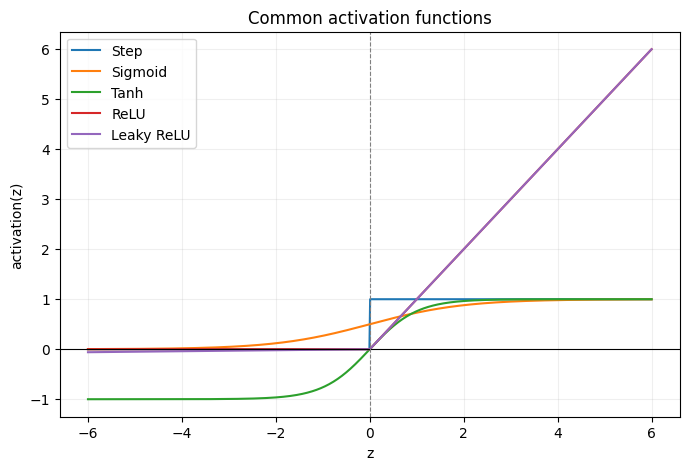

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
z = np.linspace(-6, 6, 800)

ax.plot(z, step(z), label="Step")
ax.plot(z, sigmoid(z), label="Sigmoid")
ax.plot(z, tanh(z), label="Tanh")
ax.plot(z, relu(z), label="ReLU")
ax.plot(z, leaky_relu(z), label="Leaky ReLU")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set(title="Common activation functions", xlabel="z", ylabel="activation(z)")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

# Answers:
# Sigmoid, tanh, and step are bounded. ReLU and leaky ReLU are unbounded above.
# An unbounded positive side can keep useful gradients and avoids squeezing large values.
# Step is the only discontinuous function. It also has zero derivative almost everywhere,
# so a gradient-based optimiser cannot learn through it. The other four can be used.


## Task 2 — Derivatives, and checking them numerically  

**Task 2.1.** Implement the derivative of each usable activation. Write them **in terms of
the output where you can** — that is how a real framework does it, because the forward pass
has already computed the output and recomputing it is waste.

$$\sigma'(z)=\sigma(z)\bigl(1-\sigma(z)\bigr) \qquad
\tanh'(z)=1-\tanh^2(z) \qquad
\text{ReLU}'(z)=\mathbb{1}[z>0] \qquad
\text{LeakyReLU}'_\alpha(z)=\begin{cases}1&z>0\\ \alpha&z\le0\end{cases}$$

Derive the sigmoid one yourself on paper before you type it. You will need that derivation
again for backpropagation, and it is a standard exam question.

In [4]:
def d_sigmoid(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def d_tanh(z):
    t = tanh(z)
    return 1.0 - t**2


def d_relu(z):
    z = np.asarray(z)
    return (z > 0).astype(float)


def d_leaky_relu(z, alpha=0.01):
    z = np.asarray(z)
    return np.where(z > 0, 1.0, alpha)


print(d_sigmoid(0.0), d_tanh(0.0), d_relu(1.0), d_leaky_relu(-1.0))
# expect  0.25  1.0  1.0  0.01


0.25 1.0 1.0 0.01


**Task 2.2 — the gradient check.** Do not trust a derivative you have not tested.

The central-difference approximation is

$$f'(z)\;\approx\;\frac{f(z+\varepsilon)-f(z-\varepsilon)}{2\varepsilon},$$

and it is accurate to $O(\varepsilon^2)$. Compare your analytic derivative against it using
the **relative** error

$$\text{rel err}=\frac{\lVert a-n\rVert}{\lVert a\rVert+\lVert n\rVert+10^{-12}},$$

which is scale-free, unlike an absolute difference.

Write `grad_check(f, df, z, eps=1e-5)` returning that relative error. Anything below about
$10^{-7}$ means your derivative is right; anything above $10^{-4}$ means it is wrong.

**Why $\varepsilon = 10^{-5}$ and not $10^{-12}$?** Answer in a comment — it is a question
about floating-point arithmetic, and it is worth marks.

In [5]:
def grad_check(f, df, z, eps=1e-5):
    """Compare an analytic derivative with a central-difference estimate."""
    z = np.asarray(z, dtype=float)
    numerical = (f(z + eps) - f(z - eps)) / (2.0 * eps)
    analytic = df(z)
    return np.linalg.norm(analytic - numerical) / (
        np.linalg.norm(analytic) + np.linalg.norm(numerical) + 1e-12
    )


# Keep a small gap around zero because ReLU and leaky ReLU have a corner there.
zs = np.concatenate((np.linspace(-4, -0.1, 20), np.linspace(0.1, 4, 20)))
for name, f, df in [("sigmoid", sigmoid, d_sigmoid),
                    ("tanh", tanh, d_tanh),
                    ("relu", relu, d_relu),
                    ("leaky_relu", leaky_relu, d_leaky_relu)]:
    err = grad_check(f, df, zs)
    print(f"{name:12s} relative error {err:.3e}   {'PASS' if err < 1e-7 else 'CHECK'}")

# Answer: eps = 1e-12 is too small. The two function values become almost equal,
# so subtracting them loses useful digits because computers store limited precision.
# A value near 1e-5 balances this round-off error with approximation error.


sigmoid      relative error 1.160e-11   PASS
tanh         relative error 1.337e-11   PASS
relu         relative error 3.371e-12   PASS
leaky_relu   relative error 3.372e-12   PASS


**Task 2.3.** ReLU is not differentiable at exactly $z=0$. Run the cell below, which
grad-checks ReLU on a grid that *includes* zero, and explain the result in a comment. Is
this a bug in your code, a bug in the check, or neither?

In [6]:
zs_with_zero = np.linspace(-1, 1, 21)
print("grid contains 0:", (zs_with_zero == 0).any())
print("relu grad check      :", f"{grad_check(relu, d_relu, zs_with_zero):.3e}")
print("leaky ReLU grad check:", f"{grad_check(leaky_relu, d_leaky_relu, zs_with_zero):.3e}")
print("tanh grad check      :", f"{grad_check(tanh, d_tanh, zs_with_zero):.3e}")

# Answer: ReLU and leaky ReLU have a sharp corner at zero, so there is no single true
# derivative there. Central difference averages the two sides, while our code chooses
# one side. Neither the code nor the check is broken. In practice, hitting exactly zero
# is uncommon, and using a chosen subgradient works well.


grid contains 0: True
relu grad check      : 7.857e-02
leaky ReLU grad check: 7.777e-02
tanh grad check      : 1.161e-11


## Task 3 — Saturation: where the gradient dies  

**Task 3.1.** Plot the four derivatives over $z\in[-8,8]$ on one axes. Then read off, and
print, the value of $\sigma'$ at $z=0,\,2,\,4,\,6,\,8$.

**Task 3.2.** A network multiplies one derivative per layer as the error travels backwards.
Compute $(\max_z \sigma'(z))^L$ for $L=1,2,5,10,20$ and print the numbers.

**Task 3.3.** Answer in a comment: what do those numbers tell you about training a 20-layer
sigmoid network, and which activation in your zoo does not suffer from this? This is the
reason ReLU took over.

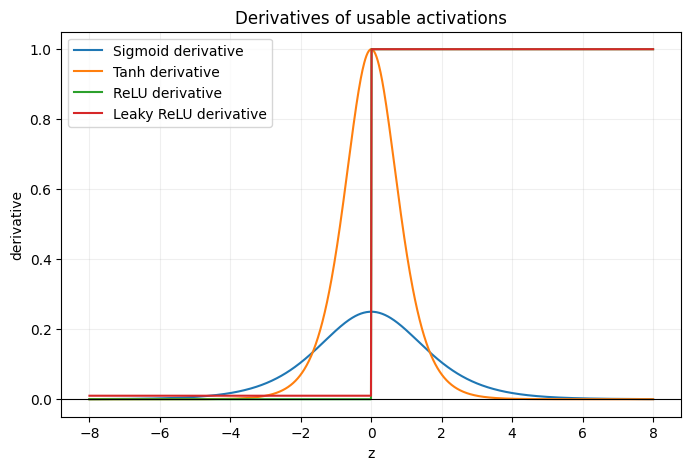

sigmoid'(0) = 0.25000000
sigmoid'(2) = 0.10499359
sigmoid'(4) = 0.01766271
sigmoid'(6) = 0.00246651
sigmoid'(8) = 0.00033524

Maximum sigmoid derivative = 0.25 at z = 0
0.25^ 1 = 2.500000000000e-01
0.25^ 2 = 6.250000000000e-02
0.25^ 5 = 9.765625000000e-04
0.25^10 = 9.536743164062e-07
0.25^20 = 9.094947017729e-13


In [7]:
z = np.linspace(-8, 8, 1000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, d_sigmoid(z), label="Sigmoid derivative")
ax.plot(z, d_tanh(z), label="Tanh derivative")
ax.plot(z, d_relu(z), label="ReLU derivative")
ax.plot(z, d_leaky_relu(z), label="Leaky ReLU derivative")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Derivatives of usable activations", xlabel="z", ylabel="derivative")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.2)
ax.legend()
plt.show()

for value in [0, 2, 4, 6, 8]:
    print(f"sigmoid'({value}) = {d_sigmoid(value):.8f}")

print("\nMaximum sigmoid derivative = 0.25 at z = 0")
for depth in [1, 2, 5, 10, 20]:
    print(f"0.25^{depth:2d} = {0.25**depth:.12e}")

# Answers:
# The sigmoid derivative is largest at z = 0, where it is 0.25.
# After 20 layers, multiplying these small derivatives can make the gradient almost zero,
# so early layers learn extremely slowly. This is the vanishing-gradient problem.
# ReLU keeps derivative 1 on its positive side, but it pays a price: a unit can get stuck
# on the negative side with derivative 0. Leaky ReLU reduces that risk with a small slope.


## Task 4 — A forward pass for an arbitrary network  
So far a forward pass has been written for one specific two-layer network. Now generalise it.

**Task 4.1.** Write `init_params(sizes, seed)` returning lists `W` and `b`, where
`sizes = [n0, n1, ..., nL]`. Use the shape convention from the lecture:

$$W^{[\ell]} \in \mathbb{R}^{\,n^{[\ell]} \times n^{[\ell-1]}},
\qquad \mathbf{b}^{[\ell]} \in \mathbb{R}^{\,n^{[\ell]}}$$

Initialise the weights from a normal distribution scaled by $\sqrt{1/n^{[\ell-1]}}$ and the
biases to zero. (Why that scale is the right one is a topic in its own right — for now, just
use it.)

**Task 4.2.** Write `forward(A0, W, b, act)` returning `(As, Zs)`: the list of activations
including the input, and the list of pre-activations. `act` is any of your Exercise 1
functions. The last layer uses the same activation as the rest for now.

**Include the `assert` statements.** They cost nothing and they turn a silent wrong answer
into a loud, located error — which will save you hours later.

In [8]:
def init_params(sizes, seed=0):
    """Create one weight matrix and one bias vector for each layer."""
    r = np.random.default_rng(seed)
    W, b = [], []

    for input_size, output_size in zip(sizes[:-1], sizes[1:]):
        # Scaling by sqrt(1 / fan-in) helps keep values from growing too much.
        W.append(r.normal(size=(output_size, input_size)) * np.sqrt(1.0 / input_size))
        b.append(np.zeros(output_size))
    return W, b


def forward(A0, W, b, act):
    """Run a batch through every layer and keep all A and Z values."""
    assert len(W) == len(b), "every weight matrix needs one bias vector"
    assert A0.ndim == 2, "A0 must have shape (examples, input features)"

    As = [A0]
    Zs = []
    current_A = A0

    for layer, (layer_W, layer_b) in enumerate(zip(W, b), start=1):
        assert layer_W.ndim == 2, f"W[{layer}] must be a matrix"
        assert layer_b.shape == (layer_W.shape[0],), f"b[{layer}] has the wrong shape"
        assert current_A.shape[1] == layer_W.shape[1], f"input width is wrong at layer {layer}"

        current_Z = current_A @ layer_W.T + layer_b
        assert current_Z.shape == (current_A.shape[0], layer_W.shape[0])
        current_A = act(current_Z)
        assert current_A.shape == current_Z.shape

        Zs.append(current_Z)
        As.append(current_A)

    return As, Zs


sizes = [3, 5, 4, 2]
W, b = init_params(sizes, seed=1)
for i, (Wi, bi) in enumerate(zip(W, b), start=1):
    print(f"W[{i}] {Wi.shape}   b[{i}] {bi.shape}")
    assert Wi.shape == (sizes[i], sizes[i - 1]), "weight matrix has the wrong shape"
    assert bi.shape == (sizes[i],), "bias vector has the wrong shape"

A0 = rng.normal(size=(8, 3))
As, Zs = forward(A0, W, b, sigmoid)
print("\nactivation shapes:", [a.shape for a in As])
assert As[-1].shape == (8, 2)
print("forward pass OK")


W[1] (5, 3)   b[1] (5,)
W[2] (4, 5)   b[2] (4,)
W[3] (2, 4)   b[3] (2,)

activation shapes: [(8, 3), (8, 5), (8, 4), (8, 2)]
forward pass OK


**Task 4.3.** Count the parameters of a network from its `sizes` list, and verify against
the lecture's MNIST example: a $784-128-64-10$ network has **109,386** parameters.

Then answer in a comment: what fraction of them sits in the *first* layer, and why is that
the motivation for convolution?

In [9]:
def count_params(sizes):
    """Count every weight and bias in the network."""
    return sum(input_size * output_size + output_size
               for input_size, output_size in zip(sizes[:-1], sizes[1:]))


mnist_sizes = [784, 128, 64, 10]
total = count_params(mnist_sizes)
first_layer = 784 * 128 + 128
first_fraction = first_layer / total

print(total)                         # expect 109386
print(count_params([2, 2, 1]))       # XOR network: expect 9
print(f"First-layer fraction: {first_fraction:.2%}")

# Answer: About 91.86% of the parameters are in the first layer. A convolution uses small
# local filters and shares the same weights across the image, so it needs far fewer weights
# than connecting every pixel to every hidden unit.


109386
9
First-layer fraction: 91.86%


## Task 5 — XOR with a smooth activation  

**Task 5.1.** Using the hand-set XOR weights below, run your general `forward` with
`step` and confirm you reproduce the lecture's trace exactly:

```
A1 = [[0,1],[1,1],[1,1],[1,0]]     y_hat = (0,1,1,0)
```

**Task 5.2.** Now run the *same weights* through `sigmoid` instead. Print the outputs.
Are they still XOR after thresholding at 0.5? How confident is the network?

**Task 5.3.** Multiply every weight and bias by 10 and run with `sigmoid` again. Explain in
a comment what changed and why — referring to what the scale of the weights does to the
pre-activations, and to the shape of the sigmoid.

This is the first time you will see that **the weights and the activation interact**, and it
matters a great deal later.

In [10]:
W_xor = [np.array([[1., 1.], [-1., -1.]]), np.array([[1., 1.]])]
b_xor = [np.array([-0.5, 1.5]), np.array([-1.5])]

# Step activation: this exactly matches XOR.
step_As, step_Zs = forward(X, W_xor, b_xor, step)
print("Step hidden layer:\n", step_As[1].astype(int))
print("Step output:", step_As[-1].ravel().astype(int))
assert np.array_equal(step_As[-1].ravel(), XOR)

# The same values with sigmoid are too soft to reproduce XOR.
sigmoid_As, sigmoid_Zs = forward(X, W_xor, b_xor, sigmoid)
sigmoid_output = sigmoid_As[-1].ravel()
print("\nSigmoid output:", sigmoid_output)
print("Thresholded output:", (sigmoid_output >= 0.5).astype(int))

# Larger parameters make the sigmoid behave more like a step.
W_scaled = [10 * layer_W for layer_W in W_xor]
b_scaled = [10 * layer_b for layer_b in b_xor]
scaled_As, scaled_Zs = forward(X, W_scaled, b_scaled, sigmoid)
scaled_output = scaled_As[-1].ravel()
print("\nScaled sigmoid output:", scaled_output)
print("Thresholded output:", (scaled_output >= 0.5).astype(int))

# Answers:
# With the original values, the smooth hidden outputs do not push the final answers far
# enough around 0.5, so thresholding gives the wrong result and confidence is low.
# Multiplying weights and biases by 10 makes the pre-activations much larger in magnitude.
# Sigmoid then moves close to 0 or 1, so the network becomes confident and gives XOR again.
# With extremely large parameters, sigmoid approaches a step function. The step is therefore
# useful as a limiting idea, even though we do not train through its zero derivative.


Step hidden layer:
 [[0 1]
 [1 1]
 [1 1]
 [1 0]]
Step output: [0 1 1 0]

Sigmoid output: [0.4244 0.4366 0.4366 0.4244]
Thresholded output: [0 0 0 0]

Scaled sigmoid output: [0.0072 0.9924 0.9924 0.0072]
Thresholded output: [0 1 1 0]


## Task 6 — Hidden units are features: seeing it

**Task 6.1.** For the hand-set XOR network, plot **three panels** over the square
$[-0.5, 1.5]^2$:

- the activation of hidden unit $h_1$ across the plane,
- the activation of hidden unit $h_2$,
- the network's final output.

Use `sigmoid` so the pictures are smooth, and `ax.contourf` with a single-hue colour map.

**Task 6.2.** Answer in a comment: each hidden unit produces a half-plane with a soft edge.
The output unit is a perceptron *over those two numbers*. Say in one sentence why that
composition can solve a problem that no single perceptron can.

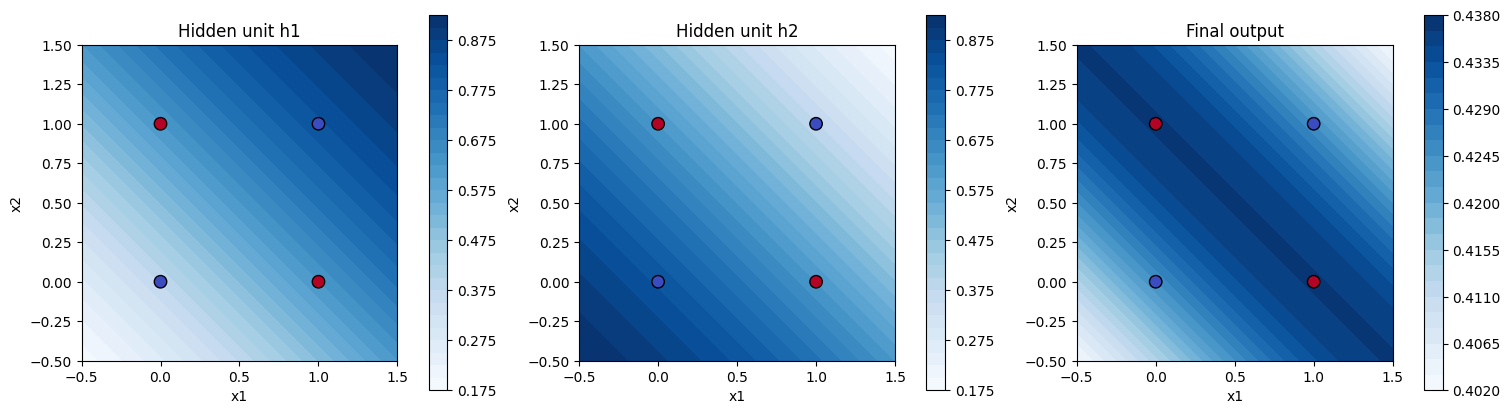

In [11]:
grid_axis = np.linspace(-0.5, 1.5, 250)
x1_grid, x2_grid = np.meshgrid(grid_axis, grid_axis)
grid_points = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
grid_As, _ = forward(grid_points, W_xor, b_xor, sigmoid)

surfaces = [
    grid_As[1][:, 0].reshape(x1_grid.shape),
    grid_As[1][:, 1].reshape(x1_grid.shape),
    grid_As[2][:, 0].reshape(x1_grid.shape),
]
titles = ["Hidden unit h1", "Hidden unit h2", "Final output"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, surface, title in zip(axes, surfaces, titles):
    contour = ax.contourf(x1_grid, x2_grid, surface, levels=30, cmap="Blues")
    ax.scatter(X[:, 0], X[:, 1], c=XOR, cmap="coolwarm", edgecolors="black", s=80)
    ax.set(title=title, xlabel="x1", ylabel="x2", aspect="equal")
    fig.colorbar(contour, ax=ax, shrink=0.85)
plt.show()

# Answer: Each hidden unit detects a different half-plane. The output mixes these two new
# features, which creates a bent decision region that one straight-line perceptron cannot make.


## ★ Optional challenge — remove the nonlinearity  

The lecture proved that a network whose activations are all the identity computes an affine
function, however deep it is. Demonstrate it numerically.

Build a $2\to8\to8\to1$ network with random weights and the identity activation. Then
compute the single equivalent matrix $A = W^{[3]}W^{[2]}W^{[1]}$ and the equivalent vector,
and show that the deep network and the one-layer model agree to floating-point precision on
a random batch.

Then state, in a comment, what this means for the XOR problem.

In [12]:
def identity(z):
    return z


linear_sizes = [2, 8, 8, 1]
linear_W, linear_b = init_params(linear_sizes, seed=7)
test_X = rng.normal(size=(12, 2))
deep_output = forward(test_X, linear_W, linear_b, identity)[0][-1]

# Combine W3(W2(W1 x + b1) + b2) + b3 into one matrix and one bias.
equivalent_W = linear_W[2] @ linear_W[1] @ linear_W[0]
equivalent_b = linear_W[2] @ (linear_W[1] @ linear_b[0] + linear_b[1]) + linear_b[2]
single_output = test_X @ equivalent_W.T + equivalent_b

max_difference = np.max(np.abs(deep_output - single_output))
print("Equivalent matrix shape:", equivalent_W.shape)
print(f"Largest difference: {max_difference:.3e}")
assert np.allclose(deep_output, single_output)

# Answer: Without nonlinear activations, extra layers still reduce to one affine layer, so
# depth adds no new kind of decision boundary and cannot solve XOR. For a 784-128-64-10
# identity network, the equivalent single weight matrix has shape (10, 784).


Equivalent matrix shape: (1, 2)
Largest difference: 1.665e-16


---

### Before you submit

- [x] Kernel → Restart & Run All, no errors and no `RuntimeWarning` from `sigmoid`.
- [x] Every `TODO` and every `raise NotImplementedError` gone.
- [x] All four gradient checks print PASS (ReLU on the grid that contains zero is expected
      to fail — say so, do not hide it).
- [x] The `assert` statements left in `forward` — they are marked.
- [x] Written answers present as comments: 1.2, 2.2, 2.3, 3.3, 4.3, 5.3, 6.2.
- [ ] Rename to `Lab3_<yourCMSID>.ipynb` after adding your CMS ID.

### One thing to take away

You now have differentiable units and a forward pass that works for any architecture. What is
still missing is a single number that says how *wrong* the whole network is — a loss function
— and a way to move the weights so as to reduce it.

Backpropagation then multiplies together exactly the derivative functions you wrote here,
layer by layer, and the nine XOR weights that were typed in by hand are finally found
automatically.